In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import geopandas as gpd
import scanpy as sc
import leidenalg
from tifffile import imread, imwrite
from csbdeep.utils import normalize
from stardist.models import StarDist2D
import squidpy as sq
from stardist.models import StarDist2D
from shapely.geometry import Polygon, Point
from scipy import sparse
from matplotlib.colors import ListedColormap
import os

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [26]:
dir_base = '/home/fceccarelli/home3/OT/data/visiumHD/'
sample = 'Pat2_W12'

print ("Segmenting sample: " + sample)

if (sample == 'Pat03_W0'):  
    filename = '/resourcefiles/Sample-001-13465.tif'
if (sample == 'Pat03_W4'):
    filename = '/resourcefiles/H1-J22N3PV-D1_Pat3_W4.tif'
if (sample == 'Pat06_W0'):
    filename = '/resourcefiles/13485_flipped.tif'
if (sample == 'Pat06_W4'):
    filename = '/resourcefiles/13472_flipped.tif'
if (sample == 'Pat14_W0'):
    filename = '/resourcefiles/Pat14_W0.tif'
if (sample == 'Pat14_W12'):
    filename = '/resourcefiles/Pat14_W12.tif'
if (sample == 'Pat14_W4'):
    filename = '/resourcefiles/Pat14_W4.tif'
if (sample == 'Pat15_W4'):
    filename = '/resourcefiles/Pat15_W4.tif'
if (sample == 'Pat2_W12'):
    filename = '/resourcefiles/Pat2_W12.tif'
if (sample == 'Pat2_W4'):
    filename = '/support/13463_flipped.tif'


img = imread(dir_base + sample + filename)

# Percentile normalization of the image
min_percentile = 5
max_percentile = 95
img = normalize(img, min_percentile, max_percentile)

print ("Extracing nuclei with StarDist")
model = StarDist2D.from_pretrained('2D_versatile_he')

labels, polys = model.predict_instances_big(img, axes='YXC', block_size=4096, prob_thresh=0.01, 
nms_thresh=0.001, min_overlap=64, context=128, normalizer=None, n_tiles=(4,4,1))

# Creating a list to store Polygon geometries
geometries = []

# Iterating through each nuclei in the 'polys' DataFrame
for nuclei in range(len(polys['coord'])):

    # Extracting coordinates for the current nuclei and converting them to (y, x) format
    coords = [(y, x) for x, y in zip(polys['coord'][nuclei][0], polys['coord'][nuclei][1])]

    # Creating a Polygon geometry from the coordinates
    geometries.append(Polygon(coords))

# Creating a GeoDataFrame using the Polygon geometries
gdf = gpd.GeoDataFrame(geometry = geometries)
gdf['id'] = [f"ID_{i+1}" for i, _ in enumerate(gdf.index)]

# Load Visium HD data
um = '008'
print ("Loading Visium HD data with bin size: " + um + "um")

raw_h5_file = dir_base + sample + '/outs/binned_outputs/square_' + um + 'um/filtered_feature_bc_matrix.h5'
adata = sc.read_10x_h5(raw_h5_file)
adata.var_names_make_unique()
print (adata)

# Load the Spatial Coordinates
tissue_position_file = dir_base + sample + '/outs/binned_outputs/square_' + um + 'um/spatial/tissue_positions.parquet'

df_tissue_positions=pd.read_parquet(tissue_position_file)

#Set the index of the dataframe to the barcodes
df_tissue_positions = df_tissue_positions.set_index('barcode')

# Create an index in the dataframe to check joins
df_tissue_positions['index']=df_tissue_positions.index

# Adding the tissue positions to the meta data
adata.obs = pd.merge(adata.obs, df_tissue_positions, left_index=True, right_index=True)

# Create a GeoDataFrame from the DataFrame of coordinates
geometry = [Point(xy) for xy in zip(df_tissue_positions['pxl_col_in_fullres'], df_tissue_positions['pxl_row_in_fullres'])]

gdf_coordinates = gpd.GeoDataFrame(df_tissue_positions, geometry=geometry)

# Perform a spatial join to check which coordinates are in a cell nucleus
result_spatial_join = gpd.sjoin(gdf_coordinates, gdf, how='left', predicate='within')

# Identify nuclei associated barcodes and find barcodes that are in more than one nucleus
result_spatial_join['is_within_polygon'] = ~result_spatial_join['index_right'].isna()
barcodes_in_overlaping_polygons = pd.unique(result_spatial_join[result_spatial_join.duplicated(subset=['index'])]['index'])
result_spatial_join['is_not_in_an_polygon_overlap'] = ~result_spatial_join['index'].isin(barcodes_in_overlaping_polygons)

# Remove barcodes in overlapping nuclei
barcodes_in_one_polygon = result_spatial_join[result_spatial_join['is_within_polygon'] & result_spatial_join['is_not_in_an_polygon_overlap']]

# The AnnData object is filtered to only contain the barcodes that are in non-overlapping polygon regions
filtered_obs_mask = adata.obs_names.isin(barcodes_in_one_polygon['index'])
filtered_adata = adata[filtered_obs_mask,:]

# Add the results of the point spatial join to the Anndata object
filtered_adata.obs = pd.merge(filtered_adata.obs, barcodes_in_one_polygon[['index','geometry','id','is_within_polygon','is_not_in_an_polygon_overlap']], left_index=True, right_index=True)

def calculate_centroid(points):
    multipoint = gpd.GeoSeries(points).unary_union
    return multipoint.centroid
    
centroids = filtered_adata.obs.groupby('id')['geometry'].apply(calculate_centroid).reset_index()
centroids = centroids.set_index('id')

# Group the data by unique nucleous IDs
groupby_object = filtered_adata.obs.groupby(['id'], observed=True)

# Extract the gene expression counts from the AnnData object
counts = filtered_adata.X

# Obtain the number of unique nuclei and the number of genes in the expression data
N_groups = groupby_object.ngroups
N_genes = counts.shape[1]

# Initialize a sparse matrix to store the summed gene counts for each nucleus
summed_counts = sparse.lil_matrix((N_groups, N_genes))

# Lists to store the IDs of polygons and the current row index
polygon_id = []
row = 0

# Iterate over each unique polygon to calculate the sum of gene counts.
for polygons, idx_ in groupby_object.indices.items():
    summed_counts[row] = counts[idx_].sum(0)
    row += 1
    polygon_id.append(polygons)

# Create and AnnData object from the summed count matrix
summed_counts = summed_counts.tocsr()
grouped_filtered_adata = anndata.AnnData(X=summed_counts, obs=pd.DataFrame(polygon_id,columns=['id'],index=polygon_id),var=filtered_adata.var)

%store grouped_filtered_adata

xs = centroids['geometry'].apply(lambda p: p.x)
ys = centroids['geometry'].apply(lambda p: p.y)
spatial_array = np.array([xs, ys]).T
grouped_filtered_adata.obsm['spatial'] = spatial_array

# Store the area of each nucleus in the GeoDataframe
gdf['area'] = gdf['geometry'].area
sc.pp.calculate_qc_metrics(grouped_filtered_adata, inplace=True)
grouped_filtered_adata

Segmenting sample: Pat2_W12
Extracing nuclei with StarDist
Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.
effective: block_size=(4096, 4096, 3), min_overlap=(64, 64, 0), context=(128, 128, 0)


100%|██████████| 154/154 [21:14<00:00,  8.28s/it]


Loading Visium HD data with bin size: 008um


anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1820): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


AnnData object with n_obs × n_vars = 400604 × 18085
    var: 'gene_ids', 'feature_types', 'genome'


3608552794.py (104): The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.


Stored 'grouped_filtered_adata' (AnnData)


AnnData object with n_obs × n_vars = 99157 × 18085
    obs: 'id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    obsm: 'spatial'

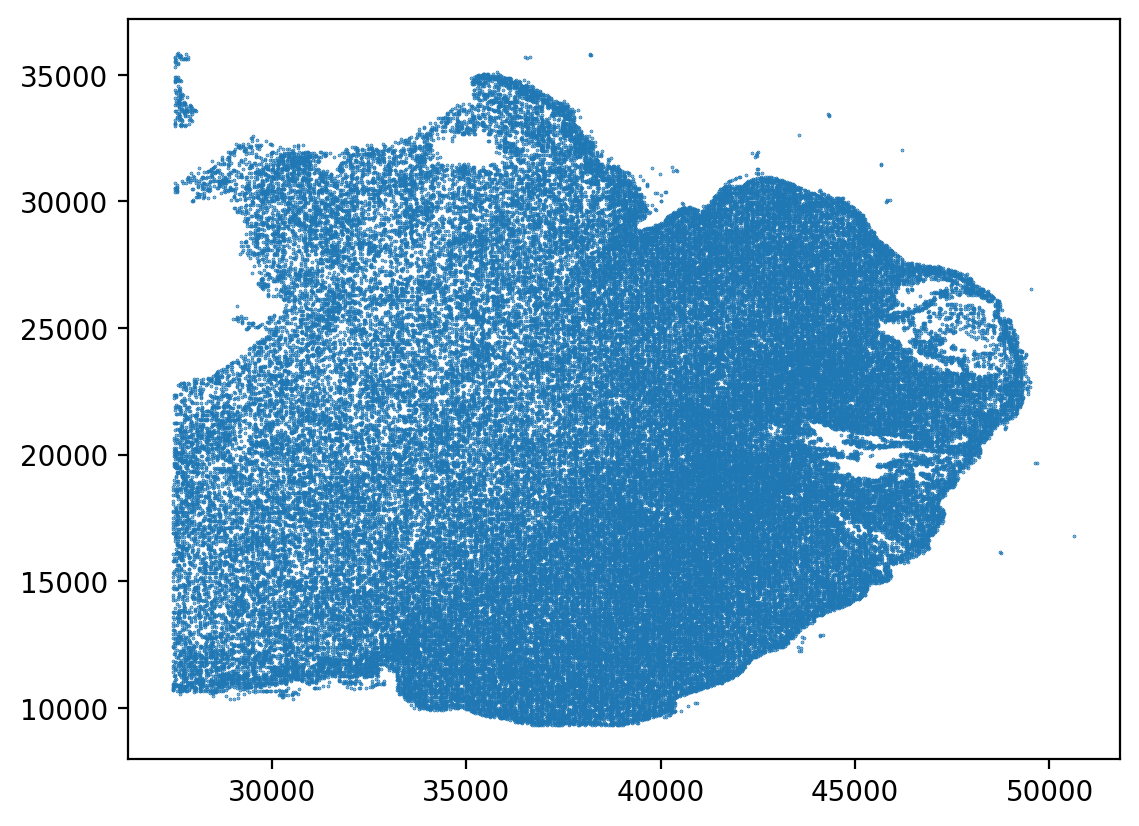

In [27]:
plt.scatter(grouped_filtered_adata.obsm["spatial"][:,0], grouped_filtered_adata.obsm["spatial"][:,1], s=0.1)

In [ ]:
new_directory_path = "segmentation/" + sample + "/"
os.makedirs(new_directory_path, exist_ok=True)
print ("Saving data to: " + new_directory_path)
expression_filename = new_directory_path + sample + "_" + um + ".h5ad"
grouped_filtered_adata.write_h5ad(expression_filename)
# geometries_filename = new_directory_path + sample + "_geometries.shp"
# gdf.to_file(geometries_filename)

Saving data to: segmentation/Pat2_W12/


: 